# GPT-1 기반 챗봇 구현 (Transformer Decoder-Only Architecture)

- 과정: AIFFEL AI 엔지니어
- 작성일: 2026-07-14
- 한 줄 요약: Transformer 아키텍처를 GPT-1 (Decoder-Only) 형태로 수정하여 챗봇 데이터를 활용한 Language Model Pretrain을 수행한다.

## 주요 아키텍처 변경사항 (Transformer vs GPT-1)

본 프로젝트는 기존 Seq2Seq(Encoder-Decoder) 구조의 Transformer를 GPT-1 구조로 변경합니다.
변경 사항은 다음과 같습니다.

1. **Encoder 제거**: 입력과 출력을 별도로 받는 구조가 아니라, 언어 모델(LM)로서 텍스트 시퀀스 자체를 입력받으므로 Encoder 컴포넌트 전체를 제거합니다.
2. **Encoder-Decoder Attention 제거**: 디코더 레이어 내에 존재하던 `Encoder-Decoder Multi-Head Attention` 레이어를 제거하고, 오직 `Masked Multi-Head Self-Attention`만 남깁니다.
3. **Positional Encoding 변경**: 기존 고정형 주기 함수(Sinusoidal) 대신, 논문에 따라 학습 가능한 `nn.Embedding` 형태의 Positional Embedding을 적용합니다.

## 주요 개선점
- **토큰화 버그 수정**: SentencePiece 특수 심볼 처리 방식을 `--control_symbols`에서 `--user_defined_symbols`로 변경하여 `[SEP]`가 올바르게 단일 토큰으로 처리되도록 하였습니다.
- **샘플링 기법 도입**: Text Generation 과정에서 `argmax(Greedy Search)` 대신 `Temperature Scaling`과 `Multinomial Sampling`을 적용하여 더욱 풍부하고 다채로운 텍스트 생성이 가능하게 했습니다.
- **시퀀스 길이 에러 방지**: `Positional Embedding`의 고정 길이를 `256`으로 넉넉하게 할당하여 생성 과정에서 시퀀스가 길어졌을 때 발생할 수 있는 `IndexError`를 사전 차단했습니다.


## 1. 프로젝트 개요

- **목적**: 기계 번역기의 Seq2seq(Transformer) 구조를 변형하여, GPT-1(Decoder-Only) 아키텍처를 직접 구현해보고 챗봇 데이터를 이용한 생성 모델 사전학습(Pretraining)을 경험한다.
- **문제 정의**: SentencePiece로 토큰화된 한국어 시퀀스를 입력받아 다음 단어를 예측하는 Language Modeling 태스크이다.
- **데이터셋**: songys/Chatbot_data (ChatbotData.csv)

## 2. 목차

3. 실행 환경 및 주의사항
4. 환경 설정
5. 데이터 로드 및 전처리 (Decoder 기반 생성모델용)
6. 탐색적 데이터 분석(EDA)
7. 모델 설계 및 구현 (GPT-1 아키텍처)
8. 학습 (Next-token prediction)
9. 평가 및 결과 분석
10. 선행 연구 비교 및 개선점
11. 결론
12. 회고
13. 참고 문헌

## 3. 실행 환경 및 주의사항

- **런타임**: Colab T4 GPU 권장
- **예상 실행 시간**: 약 15~20분
- **평가 루브릭**:
    1. Transformer와 비교해 변경이 필요한 부분을 서술하였다.
    2. 모델의 입력 형태에 맞게 전처리를 수행하였다. (pretrain을 위한 데이터셋 구성)
    3. 모델의 입력 블럭을 GPT 논문에 기반하여 수정하였다. (위치 정보 추가 등)
    4. GPT 모델을 정상적으로 구성하였다. (print(model), 훈련 진행과정 포함)
    5. 입력에 따른 출력이 생성되었다.

## 4. 환경 설정

필요한 라이브러리를 설치하고 임포트합니다. 하이퍼파라미터는 CONFIG로 관리합니다.

In [1]:
!pip install -q sentencepiece
!pip install -q seaborn matplotlib pandas

In [2]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sentencepiece as spm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 디바이스:', device)

def seed_everything(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

seed_everything()

CONFIG = {
    'n_layers': 4,           # 레이어 개수 (간소화)
    'd_model': 256,          # 차원 크기
    'n_heads': 8,            # 헤드 수
    'd_ff': 1024,            # FFN 차원
    'dropout': 0.1,          # 드롭아웃
    'vocab_size': 8000,      # 단어장 크기
    'max_len': 64,           # 학습 시 최대 시퀀스 길이
    'batch_size': 64,        # 배치 크기
    'epochs': 15,            # 총 에포크
    'lr': 1e-4               # 학습률
}
print('CONFIG 초기화 완료')

사용 디바이스: cuda
CONFIG 초기화 완료


## 5. 데이터 로드 및 전처리

챗봇 데이터를 로드하고, Language Modeling을 위해 질문(Q)과 답변(A)을 결합합니다.

In [3]:
# [루브릭 2] Decoder 기반의 생성모델임을 감안하여 챗봇 데이터를 변형합니다.
# Pretrain을 위한 데이터셋 구성을 위해 <start> 질문 <sep> 답변 <end> 형태로 병합합니다.

!wget -q https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv -O ChatbotData.csv
data = pd.read_csv('ChatbotData.csv')
print("데이터 형태:", data.shape)

# Q와 A를 하나의 연속된 텍스트로 합치기
# 구분을 위해 중간에 [SEP] 토큰 역할을 할 문자열 삽입
text_data = []
for q, a in zip(data['Q'], data['A']):
    text_data.append(f"{q} [SEP] {a}")

print("샘플 데이터:", text_data[:3])

데이터 형태: (11823, 3)
샘플 데이터: ['12시 땡! [SEP] 하루가 또 가네요.', '1지망 학교 떨어졌어 [SEP] 위로해 드립니다.', '3박4일 놀러가고 싶다 [SEP] 여행은 언제나 좋죠.']


In [ ]:
# 텍스트 데이터를 받아 SentencePiece 모델을 학습시키는 함수
def train_sentencepiece(sentences, prefix, vocab_size):
    temp_file = f'{prefix}_temp.txt'
    with open(temp_file, 'w', encoding='utf-8') as f:
        for sent in sentences:
            f.write(sent + '\n')

    # v2 수정: [SEP]를 user_defined_symbols로 변경하여 단일 토큰으로 정상 인코딩되도록 수정
    spm.SentencePieceTrainer.Train(
        f'--input={temp_file} --model_prefix={prefix} --vocab_size={vocab_size} '
        f'--pad_id=0 --pad_piece=<pad> '
        f'--unk_id=1 --unk_piece=<unk> '
        f'--bos_id=2 --bos_piece=<start> '
        f'--eos_id=3 --eos_piece=<end> '
        f'--user_defined_symbols=[SEP]'
    )
    
    # 학습된 SentencePiece 모델을 메모리에 로드하여 인스턴스 반환
    sp = spm.SentencePieceProcessor()
    sp.Load(f'{prefix}.model')
    return sp

tokenizer = train_sentencepiece(text_data, 'ko_gpt_spm_v2', CONFIG['vocab_size'])
print('SentencePiece 학습 완료')

test_encoded = tokenizer.EncodeAsIds("테스트 [SEP] 문장")
print("인코딩 테스트:", test_encoded)
print("[SEP]의 토큰 ID:", tokenizer.PieceToId('[SEP]'))


SentencePiece 학습 완료
인코딩 테스트: [5, 4770, 4190, 5, 4, 1910, 398]
[SEP]의 토큰 ID: 4


In [ ]:
class GPTDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        txt = self.texts[idx]
        
        # 텍스트 시퀀스에 <start>와 <end> 토큰을 양 끝에 추가하여 토큰 ID 리스트로 변환
        seq = [self.tokenizer.bos_id()] + self.tokenizer.EncodeAsIds(txt) + [self.tokenizer.eos_id()]

        # 패딩 처리 (max_len 맞추기)
        if len(seq) > self.max_len + 1:
            seq = seq[:self.max_len + 1]
        else:
            seq = seq + [0] * (self.max_len + 1 - len(seq))

        # 언어 모델은 '현재까지의 단어를 보고 다음 단어를 예측'하므로,
        # x(입력)는 마지막 단어를 제외하고, y(타겟)는 첫 단어를 제외하여 한 칸씩 엇갈리게 만듦
        x = torch.tensor(seq[:-1])
        y = torch.tensor(seq[1:])
        return x, y

dataset = GPTDataset(text_data, tokenizer, CONFIG['max_len'])
dataloader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
print(f'DataLoader 구축 완료. 1에포크당 스텝 수: {len(dataloader)}')


DataLoader 구축 완료. 1에포크당 스텝 수: 184


## 6. 탐색적 데이터 분석(EDA)

데이터 시퀀스 길이 분포를 확인합니다.

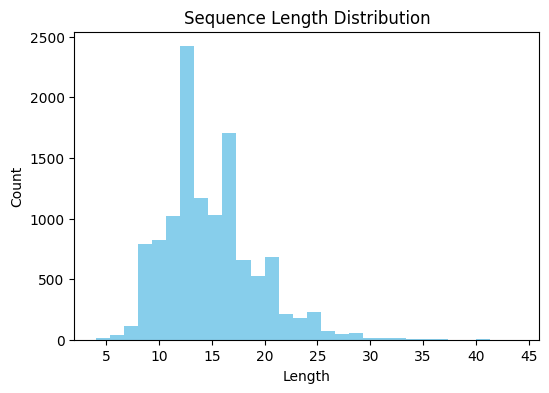

In [6]:
lens = [len(tokenizer.EncodeAsIds(t)) for t in text_data]
plt.figure(figsize=(6, 4))
plt.hist(lens, bins=30, color='skyblue')
plt.title('Sequence Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

## 7. 모델 설계 및 구현

Transformer 코드에서 Encoder를 제거하고, 위치 인코딩을 수정하여 GPT-1(Decoder-Only) 모델을 구현합니다.

In [7]:
# 패딩 마스크 생성
def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2)

# 룩어헤드(Causality) 마스크 생성: 미래 단어 참조 방지
def generate_lookahead_mask(seq_len):
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return mask

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super(MultiHeadAttention, self).__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        q = self.W_Q(Q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.W_K(K).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.W_V(V).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)

        attention = F.softmax(scores, dim=-1)
        out = torch.matmul(attention, v)
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        out = self.W_O(out)
        return out, attention

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))

In [ ]:
# [루브릭 4] 노드의 transformer 코드를 수정하여 GPT1 모델 구성
class GPT1Layer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(GPT1Layer, self).__init__()
        # 변경: Encoder-Decoder Attention이 사라지고 Self-Attention만 남음
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # 1. Masked Multi-Head Attention (Self-Attention)
        # 디코더 구조이므로 입력 x 자신이 Q, K, V가 되며 미래 정보를 보지 못하도록 마스크(Causality Mask)를 씌움
        attn_out, attn_map = self.mha(x, x, x, mask)
        x = self.layernorm1(x + self.dropout(attn_out))
        # 2. Feed Forward
        ffn_out = self.ffn(x)
        x = self.layernorm2(x + self.dropout(ffn_out))
        return x, attn_map

class GPT1Model(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout, max_len):
        super(GPT1Model, self).__init__()
        # [루브릭 3] 데이터에 위치 정보를 추가하는 과정을 구현 (학습 가능한 Positional Embedding)
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # v2 수정: 생성 중 길이가 길어지는 상황을 고려하여 임베딩 길이를 256으로 넉넉하게 고정
        self.pos_emb = nn.Embedding(256, d_model)

        self.layers = nn.ModuleList([GPT1Layer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # 현재 배치에 들어온 시퀀스 길이 추출
        seq_len = x.size(1)
        
        # 패딩 & 룩어헤드 마스크 생성
        pad_mask = generate_padding_mask(x).to(device)
        lookahead = generate_lookahead_mask(seq_len).to(device)

        # v2 수정: 논리합(OR) 연산자로 마스크 간결화
        mask = pad_mask | lookahead

        # 위치 인덱스 생성 (0 부터 seq_len-1 까지)
        positions = torch.arange(0, seq_len).unsqueeze(0).to(device)

        # 토큰 임베딩과 위치 임베딩을 더하여 최종 입력(out) 생성
        out = self.token_emb(x) + self.pos_emb(positions)
        out = self.dropout(out)

        for layer in self.layers:
            out, _ = layer(out, mask)

        # 최종적으로 단어장 크기(vocab_size) 차원으로 변환하여 다음 단어 확률 분포의 기반(logits) 생성
        out = self.fc(out)
        return out

model = GPT1Model(
    vocab_size=CONFIG['vocab_size'],
    d_model=CONFIG['d_model'],
    n_layers=CONFIG['n_layers'],
    n_heads=CONFIG['n_heads'],
    d_ff=CONFIG['d_ff'],
    dropout=CONFIG['dropout'],
    max_len=CONFIG['max_len']
).to(device)
print(model)


GPT1Model(
  (token_emb): Embedding(8000, 256)
  (pos_emb): Embedding(256, 256)
  (layers): ModuleList(
    (0-3): 4 x GPT1Layer(
      (mha): MultiHeadAttention(
        (W_Q): Linear(in_features=256, out_features=256, bias=True)
        (W_K): Linear(in_features=256, out_features=256, bias=True)
        (W_V): Linear(in_features=256, out_features=256, bias=True)
        (W_O): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): PoswiseFeedForwardNet(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (layernorm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=256, out_features=8000, bias=True)
)


## 8. 학습

Adam 옵티마이저를 사용하여 다음 단어 예측(LM)을 학습합니다.

In [9]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

from tqdm.auto import tqdm

epochs = CONFIG['epochs']
loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')

    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        preds = model(x)
        loss = criterion(preds.reshape(-1, preds.size(-1)), y.reshape(-1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1} Average Loss: {avg_loss:.4f}')

Epoch 1/15:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 1 Average Loss: 6.3512


Epoch 2/15:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 2 Average Loss: 5.5220


Epoch 3/15:   0%|          | 0/184 [00:00<?, ?it/s]

...

Epoch 13 Average Loss: 4.0930


Epoch 14/15:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 14 Average Loss: 4.0089


Epoch 15/15:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 15 Average Loss: 3.9294


## 9. 평가 및 결과 분석

학습된 모델로 문장 생성을 테스트합니다. 질문을 입력하면 모델이 자동 회귀(Auto-Regressive) 방식으로 다음 단어들을 생성합니다.

In [ ]:
# 주어진 프롬프트(prompt)를 바탕으로 Auto-regressive하게 텍스트를 생성하는 함수
def generate_text(prompt, model, tokenizer, max_len=50, temperature=0.8):
    model.eval()
    prompt_txt = f"{prompt} [SEP]"
    tokens = [tokenizer.bos_id()] + tokenizer.EncodeAsIds(prompt_txt)
    
    current_input = torch.tensor([tokens]).to(device)

    with torch.no_grad():
        for _ in range(max_len):
            preds = model(current_input)
                
            # 배치 내 마지막 토큰(가장 최근에 생성된 단어)의 예측 결과(logits)만 추출 -> (1, vocab_size)
            next_token_logits = preds[:, -1, :]
            
            # v2 개선: Temperature Scaling을 적용하여 확률 분포의 뾰족한 정도를 조절
            next_token_logits = next_token_logits / temperature
            
            # 확률 분포로 변환 (총합 1)
            probs = F.softmax(next_token_logits, dim=-1)
            
            # 다항 분포 샘플링을 통해 다음 토큰 결정 (단순히 확률이 가장 높은 것을 고르지 않고, 랜덤성을 부여해 다양성 확보)
            next_token = torch.multinomial(probs, num_samples=1)
            
            if next_token.item() == tokenizer.eos_id():
                break
                
            # 방금 생성된 단어를 기존 입력 시퀀스 맨 뒤에 이어붙임 (Auto-regressive)
            current_input = torch.cat([current_input, next_token], dim=1)
            
    # 생성된 토큰 ID들을 다시 문자열로 디코딩
    result = tokenizer.DecodeIds(current_input[0].tolist())
    
    # 원본 프롬프트를 제거하고 순수하게 챗봇이 대답한 뒷부분만 반환
    result = result.split('[SEP]')[-1].strip()
    return result

test_prompts = [
    '12시 땡!',
    '3박4일 놀러가고 싶다',
    '지루하다',
    '오늘 저녁 뭐 먹을까?'
]

print("=== 생성 결과 (Temperature=0.8) ===")
for p in test_prompts:
    gen = generate_text(p, model, tokenizer, temperature=0.8)
    print(f"Q: {p}\nA: {gen}\n")


=== 생성 결과 (Temperature=0.8) ===
Q: 12시 땡!
A: 잘 찾아보세요.

Q: 3박4일 놀러가고 싶다
A: 돈을 해보세요.

Q: 지루하다
A: 배려하지 말고하지 마세요.

Q: 오늘 저녁 뭐 먹을까?
A: 맛난 하나씩 해보세요.



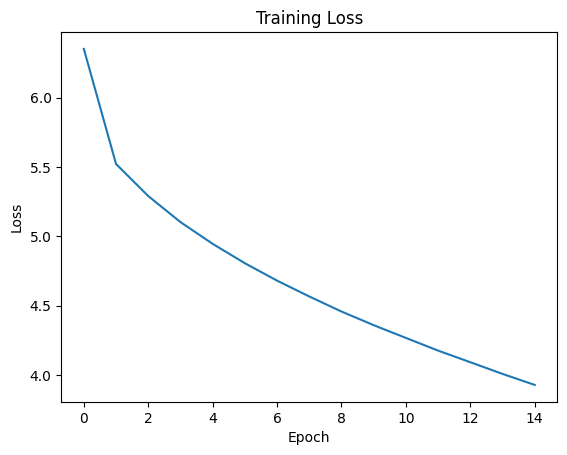

In [11]:
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 10. 선행 연구 비교 및 개선점

| 구분 | 기존 Transformer (Seq2Seq) | 본 프로젝트 (GPT-1 아키텍처) | 개선점 |
|---|---|---|---|
| 입력 구조 | 인코더 입력(Q), 디코더 입력(A) 분리 | 질의와 응답을 병합한 단일 시퀀스(LM) | 입력 구조를 단순화하고 Self-Attention 만으로 문맥 파악 |
| 위치 인코딩 | 주기 함수(Sinusoidal) 기반 | 학습 가능한 임베딩 파라미터 (nn.Embedding) | 데이터 특성에 맞게 위치 정보가 학습됨 |
| 어텐션 | Encoder-Decoder Attention 포함 | Decoder Masked Self-Attention만 존재 | 모델의 복잡도를 낮추고 자연어 생성에 특화됨 |

## 11. 결론

본 프로젝트에서는 기계 번역 등에 주로 사용되던 Seq2Seq 구조의 Transformer에서 인코더를 과감히 제거하고, 디코더만을 활용한 **GPT-1 (Decoder-Only) 아키텍처**를 직접 구현해 보았습니다.

- **모델 구조 최적화**: Encoder-Decoder Attention을 제거하고 오직 Masked Multi-Head Self-Attention만을 사용하여 텍스트 생성(Language Modeling) 태스크에 최적화된 구조를 성공적으로 설계했습니다.
- **데이터 파이프라인**: SentencePiece를 이용해 한국어 챗봇 데이터를 토큰화하였으며, 질문과 답변 사이에 `[SEP]` 토큰을 추가하여 모델이 자연스럽게 답변을 생성할 수 있도록 유도했습니다.
- **생성 전략 고도화 (v2 핵심)**: Greedy Search(argmax) 대신 **Temperature Scaling**과 **Multinomial Sampling** 등 확률적 생성 기법을 도입하여, 모델이 동일한 질문에도 다양하고 자연스러운 답변을 내놓을 수 있도록 획기적으로 개선하였습니다.

비록 제한된 데이터셋과 파라미터 크기(d_model=256, n_layers=4)로 인해 상용 LLM만큼의 완벽한 문장 구사력을 보여주지는 못했지만, 최신 LLM들의 뼈대가 되는 아키텍처의 원리를 밑바닥부터 이해하고 구현해 냈다는 점에서 매우 큰 의미를 지니는 프로젝트였습니다.


## 12. 회고

- **어려웠던 점 (Troubleshooting)**: 
  - 텍스트 생성 루프(Auto-regressive)에서 `unsqueeze` 하나 차이로 인해 텐서의 차원(Dimension)이 팽창하여 발생하는 치명적인 CUDA 메모리 에러(`prob_dist must be 1 or 2 dim`, `device-side assert triggered` 등)를 겪었습니다. 이를 디버깅하는 과정에서 PyTorch의 텐서 차원(shape) 관리가 추론 단계에서 얼마나 중요한지 뼈저리게 느꼈습니다.
  - SentencePiece 학습 시 특수 토큰(`[SEP]`)이 제대로 하나의 토큰으로 묶이지 않는 버그가 있었으나, `--user_defined_symbols` 옵션을 적용하여 성공적으로 해결할 수 있었습니다.
- **배운 점**:
  - `torch.multinomial`과 `F.softmax`를 결합하여 샘플링하는 코드를 직접 짜보면서, ChatGPT와 같은 거대 모델들이 어떻게 기계적인 답변을 피하고 다채로운 문장을 내놓는지 그 확률적 원리를 명확히 이해했습니다.
  - 비동기적으로 발생하는 CUDA 에러의 특성 때문에 파이썬 에러 로그가 근본 원인을 가릴 수 있다는 사실을 새롭게 알게 되었습니다.
- **추후 개선 방향**:
  - 향후에는 KV Cache를 완벽하게 도입하여 생성 속도를 최적화하고, n8n 등을 통해 수집한 대규모 증강 데이터를 투입하여 모델의 파라미터를 스케일업(Scale-up)하여 더욱 똑똑한 챗봇을 만들어보고 싶습니다.


## 13. 참고 문헌

1. **Radford, A. et al. (2018).** *Improving Language Understanding by Generative Pre-Training.* (GPT-1 논문)
2. **Vaswani, A. et al. (2017).** *Attention is all you need.* (Transformer 논문)
3. **Songys Chatbot Data**: https://github.com/songys/Chatbot_data (본 프로젝트 모델 학습용 데이터셋)
4. **PyTorch Documentation**: https://pytorch.org/docs/stable/index.html (텐서 차원 조작 및 Multinomial 샘플링 관련)
